# Gráficos — Financeiro (LED-38)

Consultas de [`analytics/03_consultas_financeiro.sql`](03_consultas_financeiro.sql), plotadas
para apoiar os slides de apresentação (LED-44). Conecta direto no `warehouse.duckdb` e
consulta só o modelo final (`fato_corrida` + `dim_pagamento`).

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch

con = duckdb.connect('../warehouse.duckdb', read_only=True)

# Paleta categórica validada (ordem fixa, não ciclada) - ver skill de dataviz do projeto
BLUE = '#2a78d6'    # baseline
ORANGE = '#eb6834'  # destaque
TEXT = '#0b0b0b'
MUTED = '#52514e'
GRID = '#e5e4e0'

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': MUTED,
    'axes.labelcolor': TEXT,
    'text.color': TEXT,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
    'font.size': 11,
})

def style_ax(ax, grid_axis='y'):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis=grid_axis, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)

def milhar(x, _=None):
    return f'{int(x):,}'.replace(',', '.')

## Composição do valor

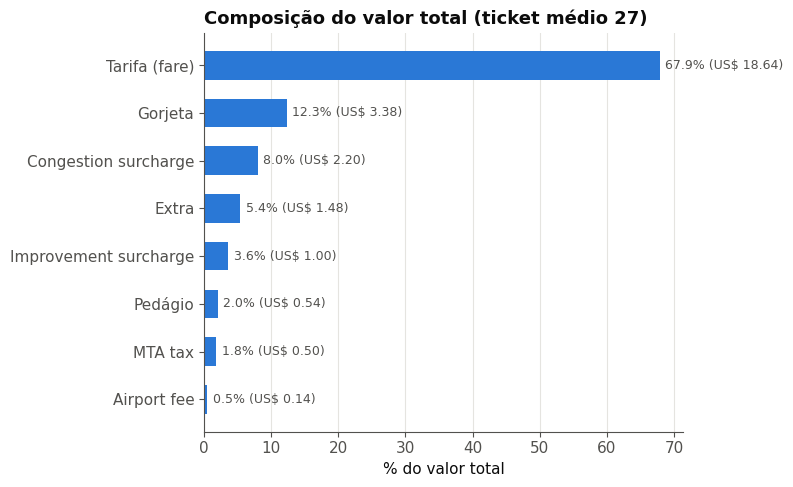

In [2]:
df = con.execute('''
    SELECT
        ROUND(AVG(fare_amount), 2) AS fare_medio,
        ROUND(AVG(extra), 2) AS extra_medio,
        ROUND(AVG(mta_tax), 2) AS mta_tax_medio,
        ROUND(AVG(tip_amount), 2) AS gorjeta_media,
        ROUND(AVG(tolls_amount), 2) AS pedagio_medio,
        ROUND(AVG(improvement_surcharge), 2) AS improvement_medio,
        ROUND(AVG(COALESCE(congestion_surcharge, 0)), 2) AS congestion_medio,
        ROUND(AVG(COALESCE(airport_fee, 0)), 2) AS airport_fee_medio,
        ROUND(AVG(total_amount), 2) AS total_medio,
        ROUND(100 * SUM(fare_amount) / SUM(total_amount), 1) AS pct_fare,
        ROUND(100 * SUM(extra) / SUM(total_amount), 1) AS pct_extra,
        ROUND(100 * SUM(mta_tax) / SUM(total_amount), 1) AS pct_mta_tax,
        ROUND(100 * SUM(tip_amount) / SUM(total_amount), 1) AS pct_gorjeta,
        ROUND(100 * SUM(tolls_amount) / SUM(total_amount), 1) AS pct_pedagio,
        ROUND(100 * SUM(improvement_surcharge) / SUM(total_amount), 1) AS pct_improvement,
        ROUND(100 * SUM(COALESCE(congestion_surcharge, 0)) / SUM(total_amount), 1) AS pct_congestion,
        ROUND(100 * SUM(COALESCE(airport_fee, 0)) / SUM(total_amount), 1) AS pct_airport_fee
    FROM fato_corrida
    WHERE total_amount > 0
''').fetchdf()

componentes = {
    'Tarifa (fare)': ('pct_fare', 'fare_medio'),
    'Gorjeta': ('pct_gorjeta', 'gorjeta_media'),
    'Congestion surcharge': ('pct_congestion', 'congestion_medio'),
    'Extra': ('pct_extra', 'extra_medio'),
    'Improvement surcharge': ('pct_improvement', 'improvement_medio'),
    'Pedágio': ('pct_pedagio', 'pedagio_medio'),
    'MTA tax': ('pct_mta_tax', 'mta_tax_medio'),
    'Airport fee': ('pct_airport_fee', 'airport_fee_medio'),
}
comp = pd.DataFrame([
    {'componente': k, 'pct': df[v[0]].iloc[0], 'valor_medio': df[v[1]].iloc[0]}
    for k, v in componentes.items()
]).sort_values('pct')

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(comp['componente'], comp['pct'], color=BLUE, height=0.6)
ax.set_title(f"Composição do valor total (ticket médio {milhar(df['total_medio'].iloc[0])})",
             loc='left', fontsize=13, fontweight='bold')
ax.set_xlabel('% do valor total')
style_ax(ax, grid_axis='x')
for b, valor in zip(bars, comp['valor_medio']):
    ax.annotate(f'{b.get_width():.1f}% (US$ {valor:.2f})', (b.get_width(), b.get_y() + b.get_height()/2),
                ha='left', va='center', fontsize=9, color=MUTED, xytext=(4, 0), textcoords='offset points')
plt.tight_layout()
plt.show()

A tarifa (fare) responde por quase 68% do valor pago; gorjeta (12,3%) já supera a soma de todas as taxas fixas (congestion + improvement + MTA + pedágio + aeroporto).

## Formas de pagamento

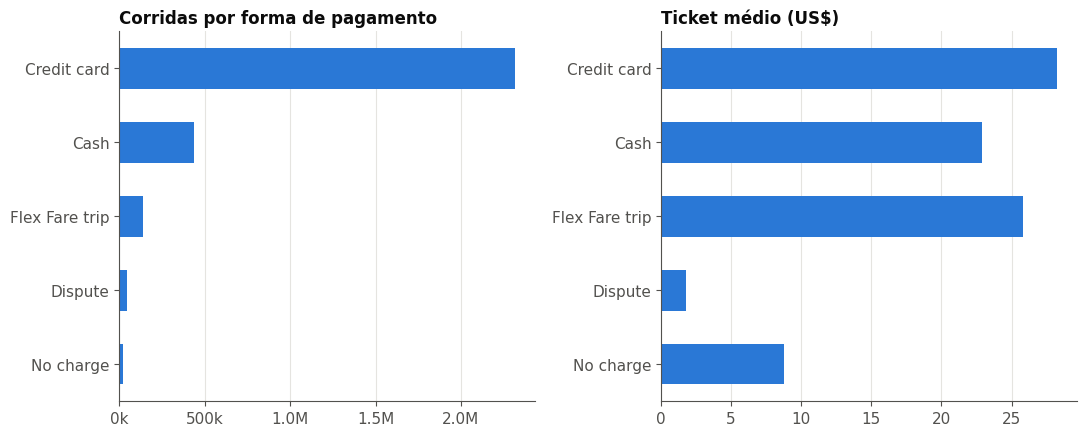

In [3]:
df = con.execute('''
    SELECT p.payment_type_desc, COUNT(*) AS qtd_corridas, ROUND(SUM(f.total_amount), 2) AS valor_total,
           ROUND(AVG(f.total_amount), 2) AS ticket_medio
    FROM fato_corrida f JOIN dim_pagamento p ON p.id_pagamento_sk = f.id_pagamento_sk
    GROUP BY p.payment_type_desc
    ORDER BY qtd_corridas DESC
''').fetchdf().sort_values('qtd_corridas')

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].barh(df['payment_type_desc'], df['qtd_corridas'], color=BLUE, height=0.55)
axes[0].set_title('Corridas por forma de pagamento', loc='left', fontsize=12, fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1000:.0f}k'))
style_ax(axes[0], grid_axis='x')

axes[1].barh(df['payment_type_desc'], df['ticket_medio'], color=BLUE, height=0.55)
axes[1].set_title('Ticket médio (US$)', loc='left', fontsize=12, fontweight='bold')
style_ax(axes[1], grid_axis='x')

plt.tight_layout()
plt.show()

Cartão de crédito domina o volume (2,32M corridas, 78%) e também o ticket médio mais alto entre as formas de pagamento regulares (US\$ 28,26); Dispute e No charge têm ticket baixo porque concentram os estornos (ver seção de estornos).

## Gorjetas

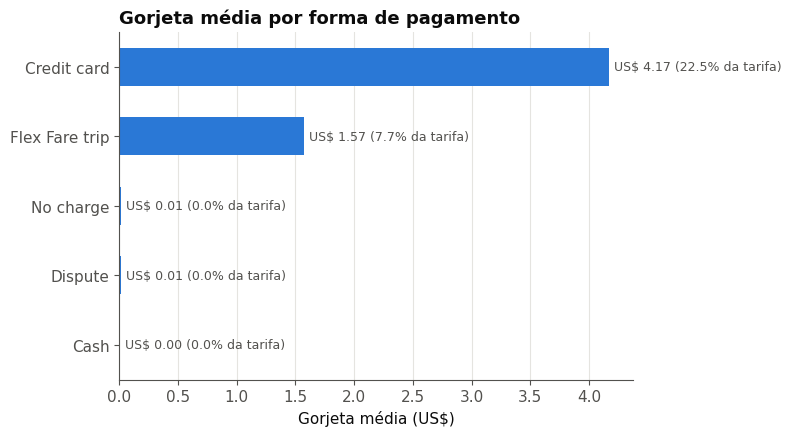

In [4]:
df = con.execute('''
    SELECT p.payment_type_desc, COUNT(*) AS qtd_corridas, ROUND(AVG(f.tip_amount), 2) AS gorjeta_media,
           ROUND(100 * SUM(f.tip_amount) / SUM(f.fare_amount), 1) AS pct_gorjeta_media
    FROM fato_corrida f JOIN dim_pagamento p ON p.id_pagamento_sk = f.id_pagamento_sk
    WHERE f.fare_amount > 0
    GROUP BY p.payment_type_desc
    ORDER BY gorjeta_media DESC
''').fetchdf().sort_values('gorjeta_media')

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(df['payment_type_desc'], df['gorjeta_media'], color=BLUE, height=0.55)
ax.set_title('Gorjeta média por forma de pagamento', loc='left', fontsize=13, fontweight='bold')
ax.set_xlabel('Gorjeta média (US$)')
style_ax(ax, grid_axis='x')
for b, pct in zip(bars, df['pct_gorjeta_media']):
    ax.annotate(f'US$ {b.get_width():.2f} ({pct:.1f}% da tarifa)', (b.get_width(), b.get_y() + b.get_height()/2),
                ha='left', va='center', fontsize=9, color=MUTED, xytext=(4, 0), textcoords='offset points')
plt.tight_layout()
plt.show()

Gorjeta relevante só existe no cartão de crédito (22,5% da tarifa, ponderado por SUM/SUM — não é a mesma coisa que a média simples da razão por corrida, que infla o número puxada pelas corridas de tarifa baixa) — dinheiro aparece com gorjeta zero porque o TLC não captura gorjeta em espécie no sistema, não porque passageiros de corrida em dinheiro não dão gorjeta.

## Pedágios

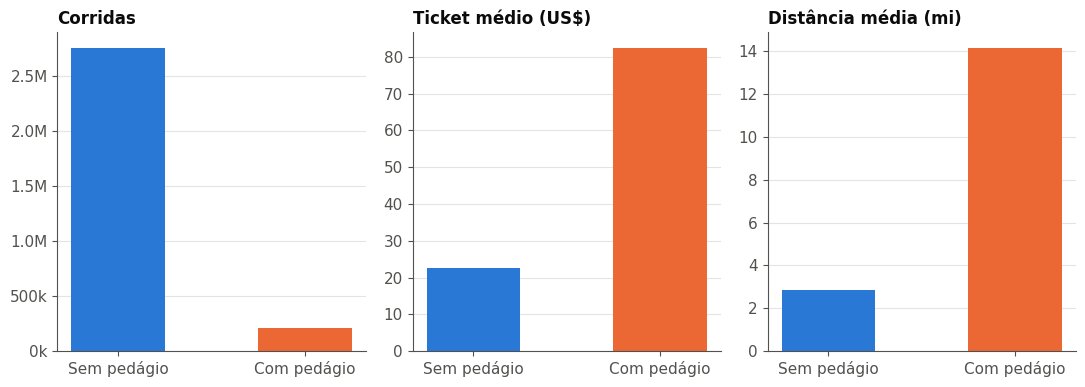

In [5]:
df = con.execute('''
    SELECT CASE WHEN tolls_amount > 0 THEN 'Com pedágio' ELSE 'Sem pedágio' END AS grupo,
           COUNT(*) AS qtd_corridas,
           ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct_corridas,
           ROUND(AVG(total_amount), 2) AS ticket_medio,
           ROUND(AVG(trip_distance), 2) AS distancia_media_mi
    FROM fato_corrida
    GROUP BY grupo
''').fetchdf()
cores = [BLUE, ORANGE]

fig, axes = plt.subplots(1, 3, figsize=(11, 4))
axes[0].bar(df['grupo'], df['qtd_corridas'], color=cores, width=0.5)
axes[0].set_title('Corridas', loc='left', fontsize=12, fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1000:.0f}k'))
style_ax(axes[0])

axes[1].bar(df['grupo'], df['ticket_medio'], color=cores, width=0.5)
axes[1].set_title('Ticket médio (US$)', loc='left', fontsize=12, fontweight='bold')
style_ax(axes[1])

axes[2].bar(df['grupo'], df['distancia_media_mi'], color=cores, width=0.5)
axes[2].set_title('Distância média (mi)', loc='left', fontsize=12, fontweight='bold')
style_ax(axes[2])

plt.tight_layout()
plt.show()

Só 7% das corridas passam por pedágio, mas são viagens bem diferentes do padrão: quase 5x mais distância (14,2mi vs. 2,9mi) e quase 4x o ticket médio (US\$ 82,51 vs. US\$ 22,58) — perfil de corrida entre boroughs/aeroportos, não deslocamento local.

## Tarifas

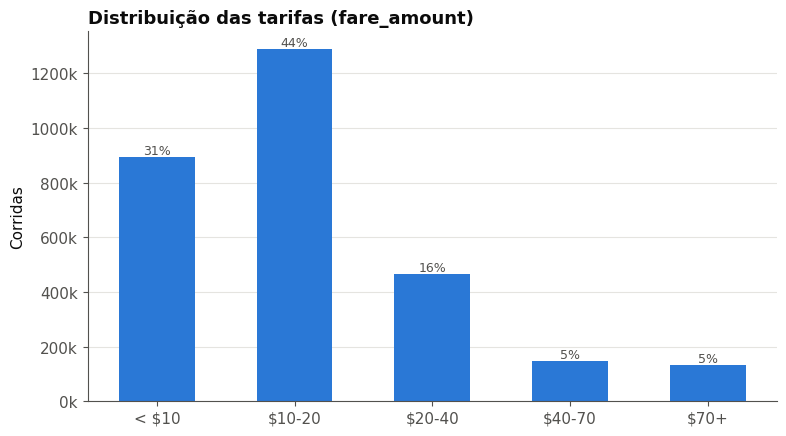

In [6]:
df = con.execute('''
    SELECT
        CASE
            WHEN fare_amount < 10 THEN '1: < $10'
            WHEN fare_amount < 20 THEN '2: $10-20'
            WHEN fare_amount < 40 THEN '3: $20-40'
            WHEN fare_amount < 70 THEN '4: $40-70'
            ELSE '5: $70+'
        END AS faixa_tarifa,
        COUNT(*) AS qtd_corridas,
        ROUND(AVG(total_amount), 2) AS ticket_medio
    FROM fato_corrida
    WHERE fare_amount >= 0
    GROUP BY faixa_tarifa
    ORDER BY faixa_tarifa
''').fetchdf()
total = df['qtd_corridas'].sum()
rotulos = ['< $10', '$10-20', '$20-40', '$40-70', '$70+']

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(rotulos, df['qtd_corridas'], color=BLUE, width=0.55)
ax.set_title('Distribuição das tarifas (fare_amount)', loc='left', fontsize=13, fontweight='bold')
ax.set_ylabel('Corridas')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
style_ax(ax)
for b, pct in zip(bars, df['qtd_corridas'] / total * 100):
    ax.annotate(f'{pct:.0f}%', (b.get_x() + b.get_width()/2, b.get_height()),
                ha='center', va='bottom', fontsize=9, color=MUTED)
plt.tight_layout()
plt.show()

Quase 3 em cada 4 corridas (73%) têm tarifa entre \$0 e \$20 — o grosso do volume é deslocamento curto/médio dentro da cidade; a cauda de \$70+ (4,5%) puxa a média geral para cima.

## Estornos e viagens com valor fora do padrão

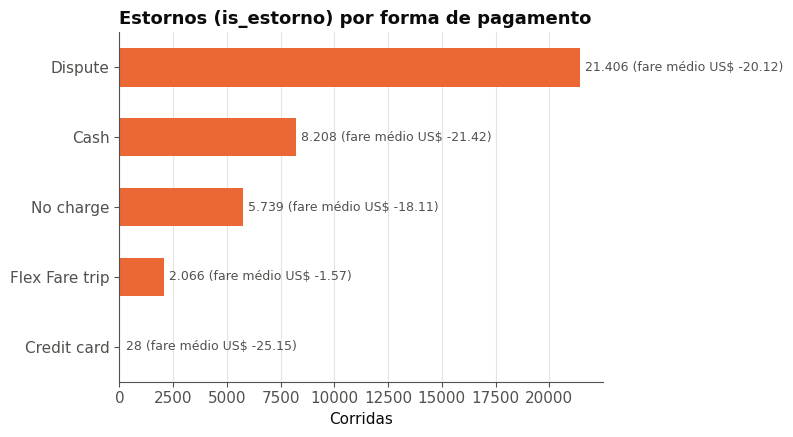

In [7]:
df = con.execute('''
    SELECT p.payment_type_desc, COUNT(*) AS qtd_corridas, ROUND(AVG(f.fare_amount), 2) AS fare_medio
    FROM fato_corrida f JOIN dim_pagamento p ON p.id_pagamento_sk = f.id_pagamento_sk
    WHERE f.is_estorno
    GROUP BY p.payment_type_desc
    ORDER BY qtd_corridas DESC
''').fetchdf().sort_values('qtd_corridas')

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(df['payment_type_desc'], df['qtd_corridas'], color=ORANGE, height=0.55)
ax.set_title('Estornos (is_estorno) por forma de pagamento', loc='left', fontsize=13, fontweight='bold')
ax.set_xlabel('Corridas')
style_ax(ax, grid_axis='x')
for b, fare in zip(bars, df['fare_medio']):
    ax.annotate(f'{milhar(b.get_width())} (fare médio US$ {fare:.2f})', (b.get_width(), b.get_y() + b.get_height()/2),
                ha='left', va='center', fontsize=9, color=MUTED, xytext=(4, 0), textcoords='offset points')
plt.tight_layout()
plt.show()

Estorno concentra quase todo o volume em Dispute e Cash (regras_limpeza.md item 2); Credit card praticamente não aparece (28 linhas) — coerente com estorno sendo um lançamento manual do motorista, não um chargeback do cartão.

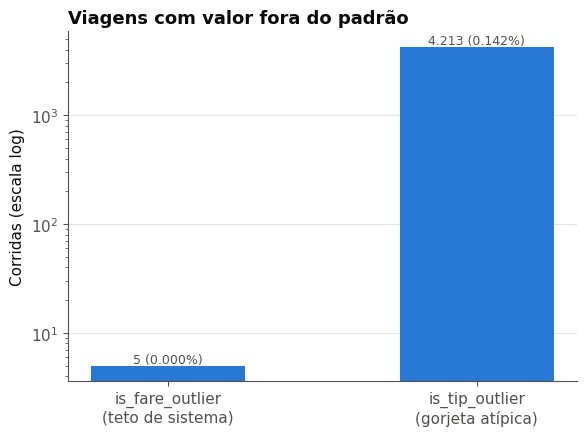

In [8]:
df = con.execute('''
    SELECT
        SUM(CASE WHEN is_fare_outlier THEN 1 ELSE 0 END) AS qtd_fare_outlier,
        SUM(CASE WHEN is_tip_outlier THEN 1 ELSE 0 END) AS qtd_tip_outlier,
        COUNT(*) AS total_corridas,
        ROUND(100.0 * SUM(CASE WHEN is_fare_outlier THEN 1 ELSE 0 END) / COUNT(*), 3) AS pct_fare_outlier,
        ROUND(100.0 * SUM(CASE WHEN is_tip_outlier THEN 1 ELSE 0 END) / COUNT(*), 3) AS pct_tip_outlier
    FROM fato_corrida
''').fetchdf()

rotulos = ['is_fare_outlier\n(teto de sistema)', 'is_tip_outlier\n(gorjeta atípica)']
valores = [df['qtd_fare_outlier'].iloc[0], df['qtd_tip_outlier'].iloc[0]]
pcts = [df['pct_fare_outlier'].iloc[0], df['pct_tip_outlier'].iloc[0]]

fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(rotulos, valores, color=BLUE, width=0.5)
ax.set_title('Viagens com valor fora do padrão', loc='left', fontsize=13, fontweight='bold')
ax.set_ylabel('Corridas (escala log)')
ax.set_yscale('log')
style_ax(ax)
for b, v, pct in zip(bars, valores, pcts):
    ax.annotate(f'{milhar(v)} ({pct:.3f}%)', (b.get_x() + b.get_width()/2, b.get_height()),
                ha='center', va='bottom', fontsize=9, color=MUTED)
plt.tight_layout()
plt.show()

`is_fare_outlier` (teto de sistema em \$5000/\$2500 exatos) é raríssimo — só 5 corridas em quase 3 milhões. `is_tip_outlier` é bem mais comum (4.213 corridas, 0,14%), mas ainda marginal: nenhuma das duas flags precisa de tratamento agressivo antes de somar receita.